In [1]:
from sqlalchemy import create_engine, text
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
engine = create_engine(
    f"mysql+mysqlconnector://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}@{os.environ['DB_HOST']}/{os.environ['DB_NAME']}"
)

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = [row[0] for row in result]

print("Total Tables:", len(tables))
print("Table Names:")
for table in tables:
    print("-", table)

Total Tables: 2
Table Names:
- apple_products_pricing_2020_2026
- clean_dataset


In [3]:
for table in tables:
       print(f"\n Table: {table}")
       query = text(f"SELECT * FROM {table}")
       df = pd.read_sql_query(query, engine)
       display(pd.read_sql(f"SELECT * FROM {table} LIMIT 5", engine))


 Table: apple_products_pricing_2020_2026


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.4,-1.6,,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.4,-1.7,,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.4,1.5,,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.7,0.9,,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.3,-1.7,,In Stock,4.7,35



 Table: clean_dataset


,date,platform,product_category,model_name,condition,launch_price_usd,launch_price_inr,current_price_usd,current_price_inr,discount_pct,sale_event,stock_status,rating,reviews_count,year,month
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.4,-1.6,No Sale Event,In Stock,4.7,40,2020,9
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.4,-1.7,No Sale Event,Out of Stock,4.6,84,2020,9
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.4,1.5,No Sale Event,In Stock,4.4,110,2020,9
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.7,0.9,No Sale Event,In Stock,4.8,111,2020,9
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.3,-1.7,No Sale Event,In Stock,4.7,35,2020,9


In [4]:
df = pd.read_sql_query(text("SELECT * FROM clean_dataset"), engine)

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,80000,2024-09-14 22:14:06.359999744,2020-09-19 00:00:00,2023-11-03 00:00:00,2024-12-22 00:00:00,2025-10-27 00:00:00,2026-07-31 00:00:00,NaN
launch_price_usd,80000.0,963.959125,329.0,599.0,799.0,1199.0,1999.0,470.086413
launch_price_inr,80000.0,94467.99425,32242.0,58702.0,78302.0,117502.0,195902.0,46068.468464
current_price_usd,80000.0,782.769855,109.93,432.93,699.74,989.1125,2038.97,461.67397
current_price_inr,80000.0,74628.342369,9157.68,41686.825,67324.05,96568.125,203669.0,45117.872002
discount_pct,80000.0,21.418826,-2.0,6.7,21.3,36.8,73.1,16.69731
rating,80000.0,4.450099,3.8,4.3,4.4,4.7,4.9,0.269782
reviews_count,80000.0,2405.995925,10.0,896.0,1893.5,3383.0,11526.0,1973.630852
year,80000.0,2024.216225,2020.0,2023.0,2024.0,2025.0,2026.0,1.405657
month,80000.0,6.401112,1.0,3.0,6.0,10.0,12.0,3.46496


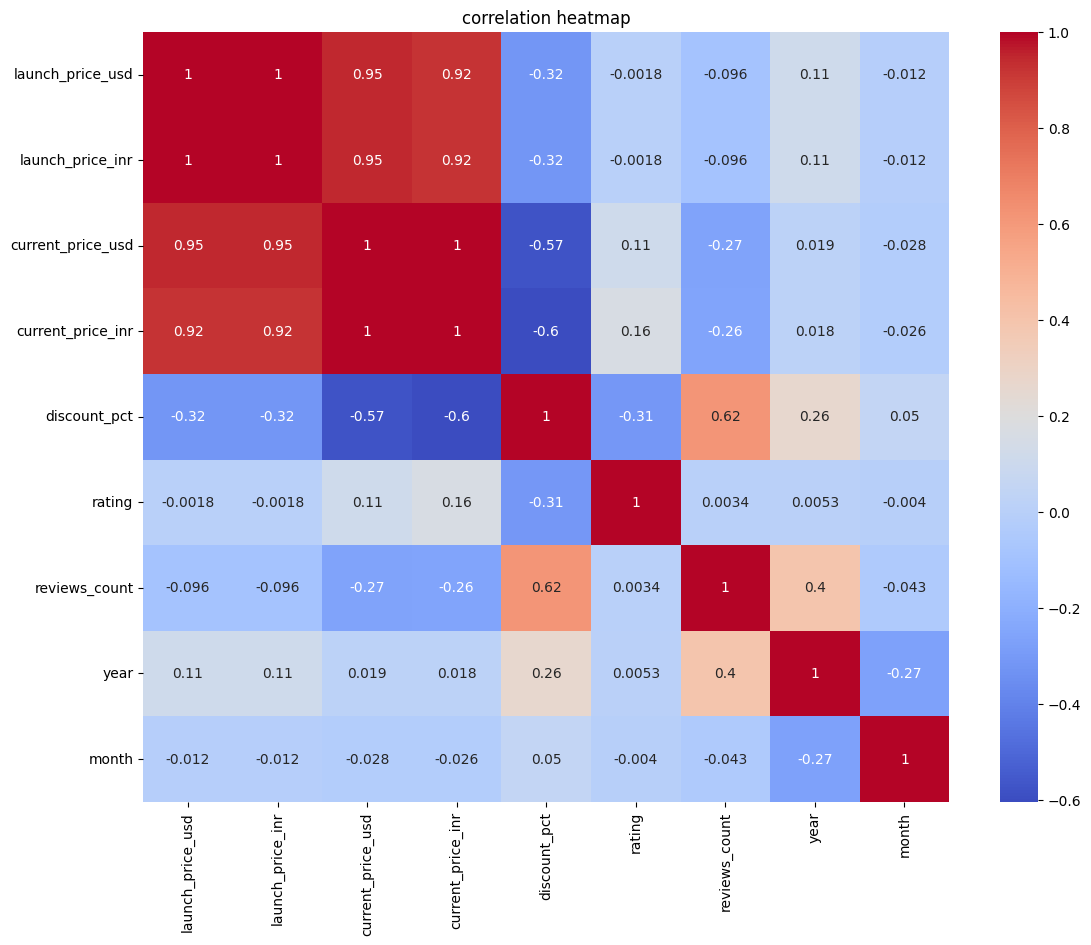

In [6]:
numeric_cols = df.select_dtypes(np.number)
plt.figure(figsize=(13,10))
sns.heatmap(numeric_cols.corr() , annot=True , cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

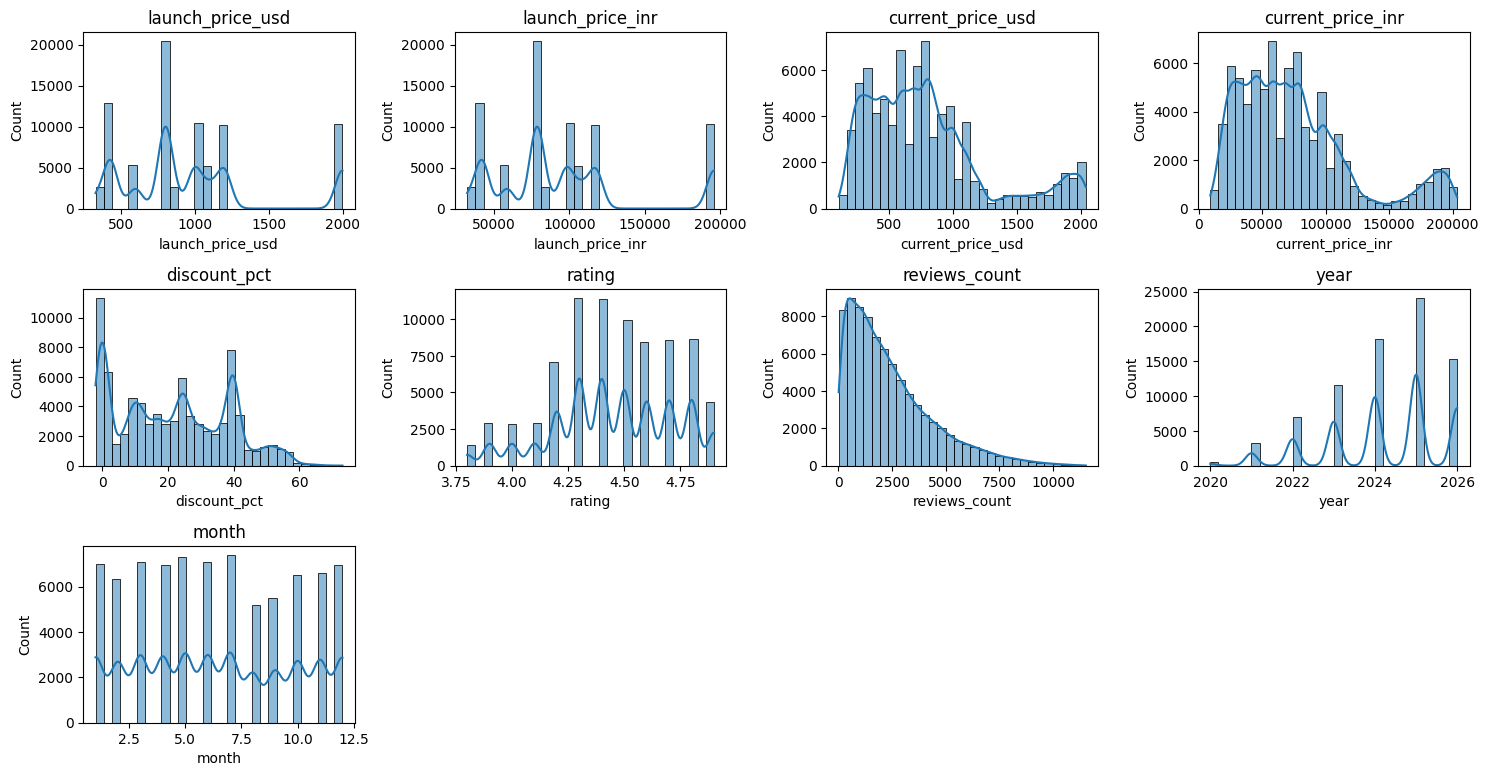

In [7]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

# Phase 1 : Business overview & KPI

1 . What is the overall average selling price and average discount offered across all Apple products?

In [16]:
overall_price = pd.read_sql_query(text("""select round(avg(current_price_inr),2) as avg_price_current , round(avg(discount_pct),2) as avg_discount_offer from clean_dataset; """),engine)
display(overall_price)

,avg_price_current,avg_discount_offer
0,74628.34,21.42


2 . How does average price differ across product categories (iPhone, iPad, Mac, Watch)?


,product_category,avg_price_current
0,Mac,131766.94
1,iPhone,72370.86
2,iPad,54633.86
3,Watch,37983.28


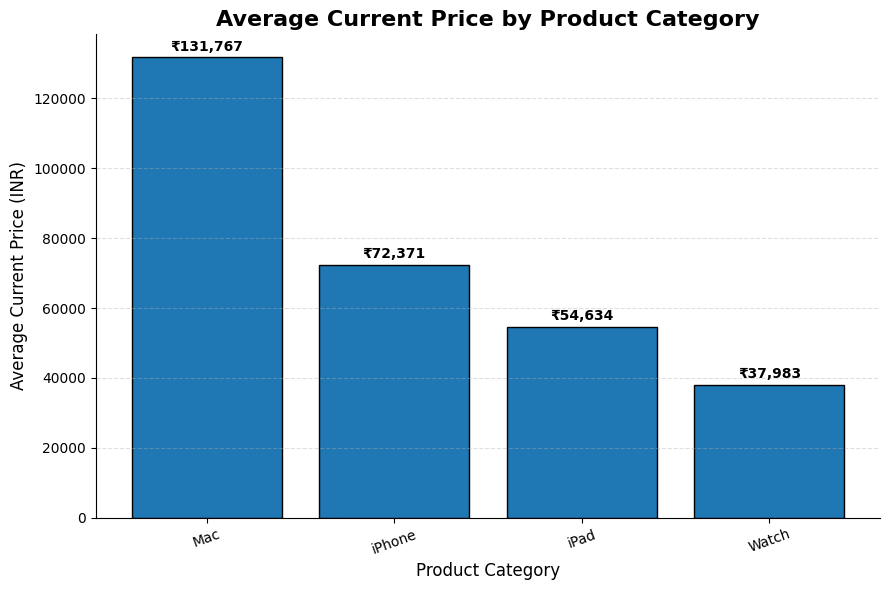

In [23]:
category_distribution = pd.read_sql_query(text("""select product_category , round(avg(current_price_inr),2) as avg_price_current from clean_dataset group by product_category order by avg_price_current desc"""),engine)
display(category_distribution)

plt.figure(figsize=(9,6))

bars = plt.bar(
    category_distribution["product_category"],
    category_distribution["avg_price_current"],
    edgecolor="black"
)

# Data labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1000,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Average Current Price by Product Category",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Average Current Price (INR)", fontsize=12)

plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.4)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

3 . What is the total review volume and average rating across the entire catalog, and what does it suggest about customer engagement?

In [18]:
catalog = pd.read_sql_query(text("""select sum(reviews_count) as total_review , round(avg(rating),2) avg_rating from clean_dataset; """),engine)
display(catalog)

,total_review,avg_rating
0,192479674.0,4.45


**The high review volume + high average rating is a very positive signal.**
**It suggests that the catalog is not only popular but also well-received by customers.**


4 . Which product category contributes the most "market activity" (listings × reviews) and can be considered the business's core revenue driver?

,product_category,listing,total_review,market_activity
0,iPhone,28589,65187205.0,1.863637e+12
1,Watch,17865,42520463.0,7.596281e+11
2,Mac,18020,41174963.0,7.419728e+11
3,iPad,15526,43597043.0,6.768877e+11


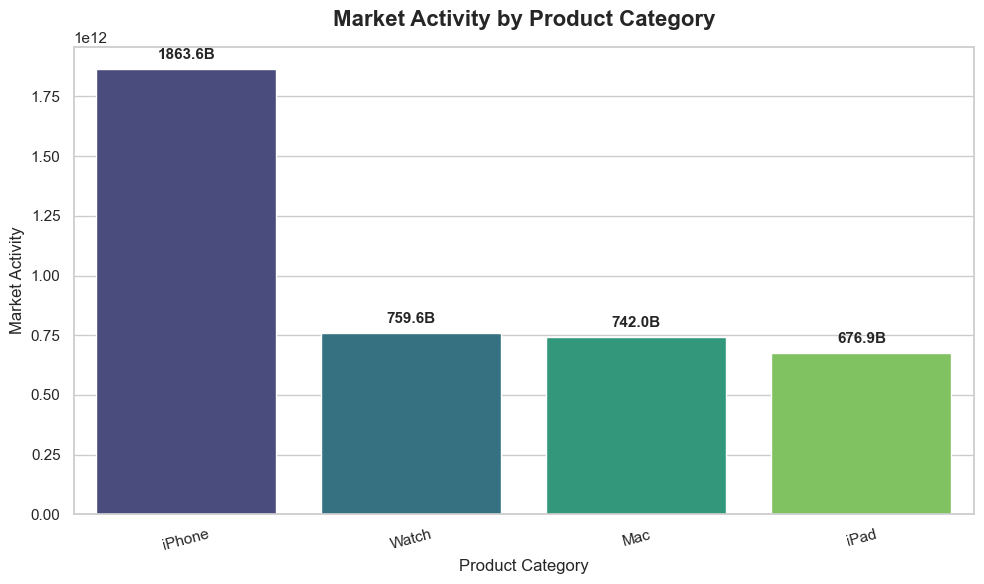

In [26]:
market_activity = pd.read_sql_query(text("""select product_category , count(*) as listing ,
sum(reviews_count) as total_review , round(count(*) * sum(reviews_count),2) as market_activity from clean_dataset group by product_category order by market_activity desc"""),engine)
display(market_activity)

# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(10,6))

# Bar plot
ax = sns.barplot(
    data=market_activity,
    x="product_category",
    y="market_activity",
    palette="viridis"
)

# Title & Labels
ax.set_title("Market Activity by Product Category", fontsize=16, weight='bold', pad=15)
ax.set_xlabel("Product Category", fontsize=12)
ax.set_ylabel("Market Activity", fontsize=12)

# Function to format large numbers
def format_number(num):
    if num >= 1_000_000_000:
        return f'{num/1_000_000_000:.1f}B'
    elif num >= 1_000_000:
        return f'{num/1_000_000:.1f}M'
    elif num >= 1_000:
        return f'{num/1_000:.1f}K'
    else:
        return f'{num:.0f}'

# Add data labels
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        format_number(height),
        (bar.get_x() + bar.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        xytext=(0,5),
        textcoords='offset points'
    )

# Rotate x-axis labels if needed
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

5 . How has the average discount percentage evolved from 2020 to 2026 — is Apple's pricing becoming more aggressive over time?

In [ ]:
avg_discount = pd.read_sql_query(text("""select year , round(avg(discount_pct),2) as avg_discount from clean_dataset group by year"""),engine)
display(avg_discount)

,year,avg_discount
0,2020,8.71
1,2021,9.18
2,2022,14.23
3,2023,18.50
4,2024,21.00
5,2025,23.88
6,2026,26.57
